In [1]:
import os
import random
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms

import timm
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier


In [2]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.1,0.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225])
])

In [3]:
!pip install pytorch-metric-learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 94.0 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.2

In [4]:
from pytorch_metric_learning.samplers import MPerClassSampler
from pytorch_metric_learning import miners, losses

In [5]:
class ClothingDataset(Dataset):

    def __init__(self, samples, transform=None):

        self.samples = samples
        self.transform = transform

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        img_path, label = self.samples[idx]

        img = Image.open(
            img_path
        ).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

In [6]:
def collect_samples(root_dir):

    samples = []

    label_to_idx = {}

    current_label = 0

    for top_folder in os.listdir(root_dir):

        top_path = os.path.join(
            root_dir,
            top_folder
        )

        if not os.path.isdir(top_path):
            continue

        for class_name in os.listdir(top_path):

            class_path = os.path.join(
                top_path,
                class_name
            )

            if not os.path.isdir(class_path):
                continue

            class_id = (
                top_folder
                + "_"
                + class_name
            )

            if class_id not in label_to_idx:

                label_to_idx[
                    class_id
                ] = current_label

                current_label += 1

            label = label_to_idx[
                class_id
            ]

            for img_name in os.listdir(class_path):

                img_path = os.path.join(
                    class_path,
                    img_name
                )

                samples.append(
                    (img_path, label)
                )

    return samples

In [7]:
all_samples = collect_samples(
    "/kaggle/input/datasets/afqwe0/clotheslabelled"
)

In [8]:
from sklearn.model_selection import train_test_split
from collections import defaultdict

In [9]:
class_samples = defaultdict(list)

for path, label in all_samples:

    class_samples[label].append(
        (path, label)
    )

In [10]:
train_samples = []
val_samples = []
test_samples = []

for label in class_samples:

    images = class_samples[label]

    train, temp = train_test_split(
        images,
        test_size=0.30,
        random_state=42
    )

    val, test = train_test_split(
        temp,
        test_size=0.50,
        random_state=42
    )

    train_samples.extend(train)
    val_samples.extend(val)
    test_samples.extend(test)

In [11]:
original_dataset = ClothingDataset(
    all_samples, 
    transform
)
train_dataset = ClothingDataset(
    train_samples,
    transform
)

val_dataset = ClothingDataset(
    val_samples,
    transform
)

test_dataset = ClothingDataset(
    test_samples,
    transform
)

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def show_augmented_images(dataset, num_images=6):

    plt.figure(figsize=(15,8))

    for i in range(num_images):

        image, label = dataset[i]

        image = image.permute(1, 2, 0).numpy()

        image = image * 0.5 + 0.5
        image = np.clip(image, 0, 1)

        plt.subplot(2, 3, i+1)
        plt.imshow(image)
        plt.title(f"Label: {label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

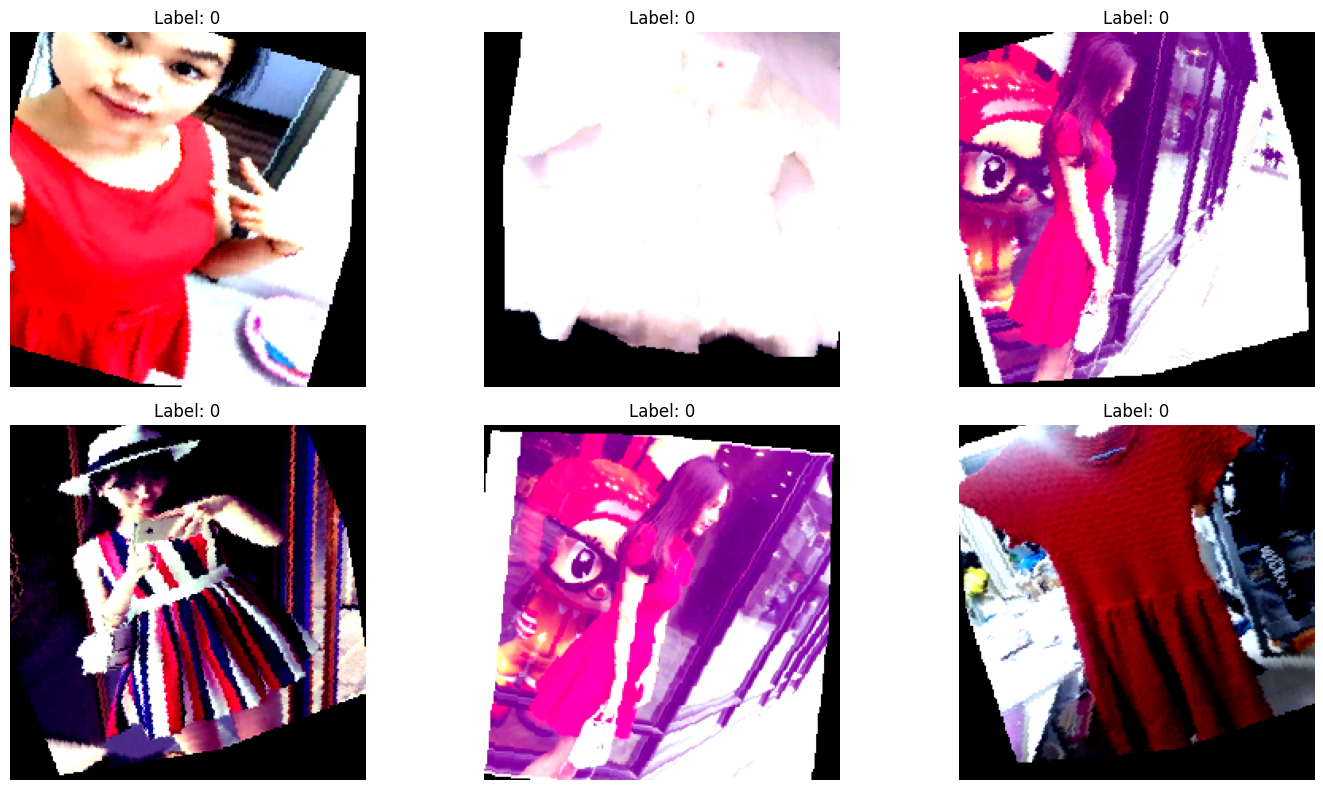

In [13]:
show_augmented_images(train_dataset)

In [14]:
train_labels = [

    sample[1]

    for sample in train_samples
]
train_sampler = MPerClassSampler(

    train_labels,
    m=4,
    batch_size=32,
    length_before_new_iter=len(train_dataset)
)

In [15]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    sampler=train_sampler
)

In [16]:
val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False
)

In [17]:
def evaluate(model, loader):

    model.eval()

    embeddings = []
    labels = []

    with torch.no_grad():

        for images, batch_labels in loader:

            images = images.to(device)

            emb = model(images)

            embeddings.append(
                emb.cpu()
            )

            labels.append(
                batch_labels
            )

    embeddings = torch.cat(
        embeddings
    )

    labels = torch.cat(
        labels
    )

    similarity = torch.matmul(

        embeddings,

        embeddings.T
    )

    # remove self-match
    similarity.fill_diagonal_(
        -999
    )

    nearest = torch.argmax(
        similarity,
        dim=1
    )

    predicted = labels[
        nearest
    ]

    accuracy = (

        predicted == labels
    ).float().mean()

    return accuracy.item()

In [18]:
def validation_loss(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            embeddings = model(images)
            hard_triplets = miner(
                embeddings,
                labels
            )
            loss = loss_func(
                embeddings,
                labels,
                hard_triplets
            )
            total_loss += loss.item()
    return total_loss / len(loader)

In [19]:
class MobileNetV4Embedding(
    nn.Module
):
    def __init__(
        self,
        embedding_dim=128
    ):
        super().__init__()

        self.backbone = timm.create_model(
            "mobilenetv4_conv_large.e500_r256_in1k",
            pretrained=True,
            num_classes=0
        )

        self.embedding = nn.Linear(
            1280,
            embedding_dim
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.embedding(x)

        x = F.normalize(
            x,
            p=2,
            dim=1
        )

        return x

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MobileNetV4Embedding().to(device)

for param in model.backbone.parameters():
    param.requires_grad = True

model.safetensors:   0%|          | 0.00/131M [00:00<?, ?B/s]

In [21]:
miner = miners.TripletMarginMiner(
    margin=0.4,
    type_of_triplets="semihard"
)

loss_func = losses.TripletMarginLoss(
    margin=0.4
)

In [22]:
optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)

train_losses = []
val_losses = []
val_accuracies = []

In [23]:
from tqdm.auto import tqdm

best_val_acc = 0

epochs = 30

for epoch in range(epochs):

    model.train()

    total_loss = 0

    progress_bar = tqdm(

        train_loader,

        desc=f"Epoch {epoch+1}/{epochs}"
    )

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        embeddings = model(
            images
        )

        hard_triplets = miner(

            embeddings,

            labels
        )

        loss = loss_func(

            embeddings,

            labels,

            hard_triplets
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        avg_loss = (

            total_loss /

            (progress_bar.n + 1)
        )

        progress_bar.set_postfix({

            "loss":
            f"{avg_loss:.4f}"
        })

    epoch_loss = (
        total_loss /
        len(train_loader)
    )

    print(
        f"Epoch {epoch+1}"
        f" | Train Loss {epoch_loss:.4f}"
    )

    train_losses.append(epoch_loss)

    val_acc = evaluate(
        model,
        val_loader
    )
    val_loss = validation_loss(
        model,
        val_loader
    )

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Validation Accuracy:"
        f" {val_acc:.4f}"
        f" Validation Loss: {val_loss:.4f}"
    )
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

        print(
            "Saved best model"
        )

Epoch 1/30:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 1 | Train Loss 0.2274
Validation Accuracy: 0.4133 Validation Loss: 0.1765
Saved best model


Epoch 2/30:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 2 | Train Loss 0.1876
Validation Accuracy: 0.5222 Validation Loss: 0.1647
Saved best model


Epoch 3/30:   0%|          | 0/65 [00:00<?, ?it/s]

...

Epoch 28 | Train Loss 0.0581
Validation Accuracy: 0.8467 Validation Loss: 0.1376


Epoch 29/30:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 29 | Train Loss 0.0847
Validation Accuracy: 0.8689 Validation Loss: 0.1295
Saved best model


Epoch 30/30:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 30 | Train Loss 0.0705
Validation Accuracy: 0.8400 Validation Loss: 0.1223


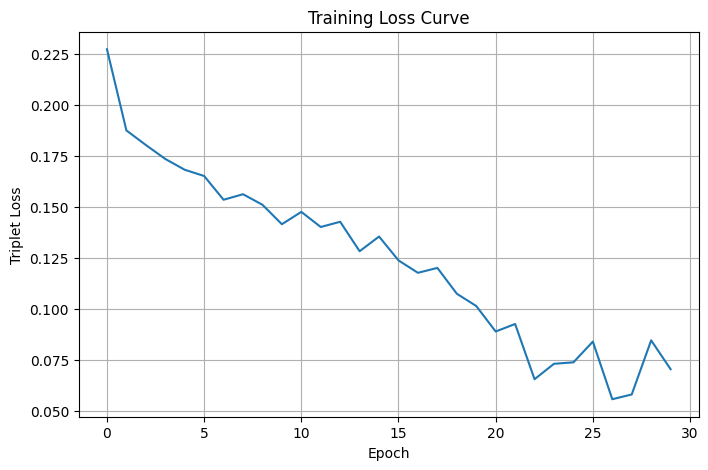

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Triplet Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

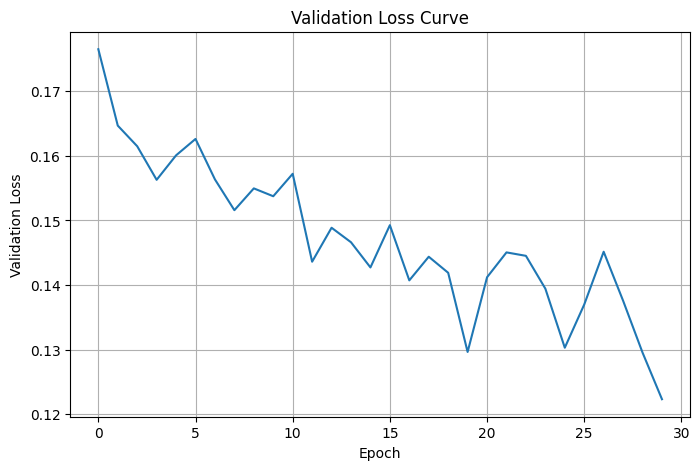

In [25]:
plt.figure(figsize=(8,5))
plt.plot(val_losses)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curve")
plt.grid(True)
plt.show()

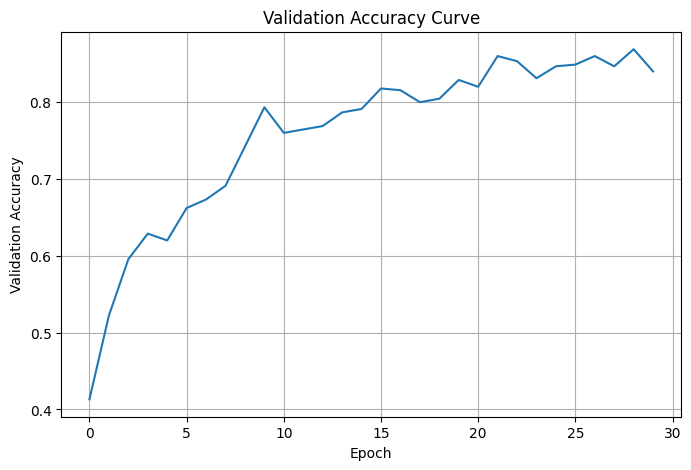

In [26]:
plt.figure(figsize=(8,5))
plt.plot(val_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Curve")
plt.grid(True)
plt.show()

In [27]:
model.load_state_dict(

    torch.load(
        "best_model.pth"
    )
)

<All keys matched successfully>

In [28]:
test_acc = evaluate(

    model,

    test_loader
)

print(
    "Final Test Accuracy:",
    test_acc
)

Final Test Accuracy: 0.8156182169914246


In [29]:
from sklearn.manifold import TSNE
import seaborn as sns

model.eval()

embeddings = []
labels = []

with torch.no_grad():

    for images, batch_labels in test_loader:

        images = images.to(device)

        emb = model(images)

        embeddings.append(emb.cpu())

        labels.extend(batch_labels.numpy())

embeddings = torch.cat(embeddings).numpy()

In [30]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

reduced = tsne.fit_transform(embeddings)

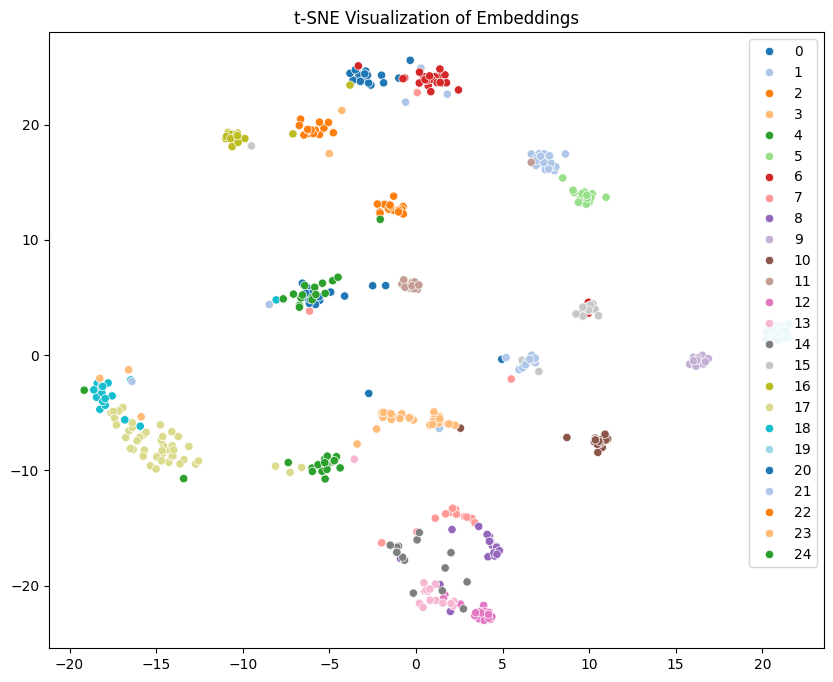

In [31]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x=reduced[:,0],
    y=reduced[:,1],
    hue=labels,
    palette="tab20"
)

plt.title("t-SNE Visualization of Embeddings")
plt.show()